In [20]:
import numpy as np 
import pandas as pd

In [21]:
import os
for dirname, _, filenames in os.walk(r'C:\Users\black\Portofolio\My-Portofolio\Deep Learning\Convolutional neural network (CNN)\Skin cancer ISIC The International Skin Imaging Collaboration'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

C:\Users\black\Portofolio\My-Portofolio\Deep Learning\Convolutional neural network (CNN)\Skin cancer ISIC The International Skin Imaging Collaboration\Skin Cancer Detection using CNN.ipynb
C:\Users\black\Portofolio\My-Portofolio\Deep Learning\Convolutional neural network (CNN)\Skin cancer ISIC The International Skin Imaging Collaboration\.ipynb_checkpoints\Skin Cancer Detection using CNN-checkpoint.ipynb
C:\Users\black\Portofolio\My-Portofolio\Deep Learning\Convolutional neural network (CNN)\Skin cancer ISIC The International Skin Imaging Collaboration\Test\actinic keratosis\ISIC_0010512.jpg
C:\Users\black\Portofolio\My-Portofolio\Deep Learning\Convolutional neural network (CNN)\Skin cancer ISIC The International Skin Imaging Collaboration\Test\actinic keratosis\ISIC_0010889.jpg
C:\Users\black\Portofolio\My-Portofolio\Deep Learning\Convolutional neural network (CNN)\Skin cancer ISIC The International Skin Imaging Collaboration\Test\actinic keratosis\ISIC_0024468.jpg
C:\Users\black\Port

In [22]:
# importing basic libraries

import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob ## glob is used to retrieve files 

# set seed
np.random.seed(21)

In [23]:
from PIL import Image
import os
import numpy as np

# Fix the file paths by either using raw strings (r prefix) or double backslashes or forward slashes
directory_melanoma_train = r'C:\Users\black\Portofolio\My-Portofolio\Deep Learning\Convolutional neural network (CNN)\Skin cancer ISIC The International Skin Imaging Collaboration\Train\melanoma'
directory_nevus_train = r'C:\Users\black\Portofolio\My-Portofolio\Deep Learning\Convolutional neural network (CNN)\Skin cancer ISIC The International Skin Imaging Collaboration\Train\nevus'
directory_melanoma_test = r'C:\Users\black\Portofolio\My-Portofolio\Deep Learning\Convolutional neural network (CNN)\Skin cancer ISIC The International Skin Imaging Collaboration\Test\melanoma'
directory_nevus_test = r'C:\Users\black\Portofolio\My-Portofolio\Deep Learning\Convolutional neural network (CNN)\Skin cancer ISIC The International Skin Imaging Collaboration\Test\nevus'

## Loading images and converting them to numpy array using their RGB value
read = lambda imname: np.asarray(Image.open(imname).convert('RGB'))
# np.asarray converts the objects into array/list

# Loading train images
img_melanoma_train = [read(os.path.join(directory_melanoma_train, filename)) for filename in os.listdir(directory_melanoma_train)]
img_nevus_train = [read(os.path.join(directory_nevus_train, filename)) for filename in os.listdir(directory_nevus_train)]

# Loading test images
img_melanoma_test = [read(os.path.join(directory_melanoma_test, filename)) for filename in os.listdir(directory_melanoma_test)]
img_nevus_test = [read(os.path.join(directory_nevus_test, filename)) for filename in os.listdir(directory_nevus_test)]

#img_benign_train
type(img_melanoma_train)

list

In [24]:
# Converting list to numpy array for faster and more convenient operations going forward

# Option 1: Resize all images to the same dimensions first
import numpy as np
from skimage.transform import resize

# Define a standard size for all images (e.g., 224x224 pixels)
standard_size = (224, 224, 3)  # Height, Width, Channels

# Function to resize images to standard size
def resize_images(img_list, target_size):
    resized_list = [resize(img, target_size, preserve_range=True).astype('uint8') 
                    for img in img_list]
    return np.array(resized_list)

# Resize and convert to numpy arrays
X_melanoma_train = resize_images(img_melanoma_train, standard_size)
X_nevus_train = resize_images(img_nevus_train, standard_size)
X_melanoma_test = resize_images(img_melanoma_test, standard_size)
X_nevus_test = resize_images(img_nevus_test, standard_size)

# Alternative Option 2: If you want to keep original dimensions but still use numpy
# X_melanoma_train = np.array(img_melanoma_train, dtype=object)  # Use dtype=object for arrays with different shapes

type(X_melanoma_train)

numpy.ndarray

In [25]:
## Creating labels: benign is 0 and malignant is 1

y_melanoma_train = np.zeros(X_melanoma_train.shape[0])
y_nevus_train = np.ones(X_nevus_train.shape[0])

y_melanoma_train = np.zeros(X_melanoma_test.shape[0])
y_nevus_train = np.ones(X_nevus_test.shape[0])

y_nevus_train

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [26]:
# First, define all the required arrays
# Note: You'll need to replace these with your actual data loading code
X_melanoma_train = np.array([...])  # Your melanoma training images
X_nevus_train = np.array([...])     # Your nevus training images
y_melanoma_train = np.array([...])  # Your melanoma training labels
y_nevus_train = np.array([...])     # Your nevus training labels

X_melanoma_test = np.array([...])   # Your melanoma test images
X_nevus_test = np.array([...])      # Your nevus test images
y_melanoma_test = np.array([...])   # Your melanoma test labels - This was missing
y_nevus_test = np.array([...])      # Your nevus test labels

## Merge data to form complete training and test sets
# axis = 0 means rows
X_train = np.concatenate((X_melanoma_train, X_nevus_train), axis=0) 
y_train = np.concatenate((y_melanoma_train, y_nevus_train), axis=0)

X_test = np.concatenate((X_melanoma_test, X_nevus_test), axis=0)
y_test = np.concatenate((y_melanoma_test, y_nevus_test), axis=0)

print("Shape of X_train: ", X_train.shape) # one image constitutes to (224, 224, 3) and we have 2637 total images in training set
print("Shape of y_train: ", y_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of y_test: ", y_test.shape)

y_test

Shape of X_train:  (2,)
Shape of y_train:  (2,)
Shape of X_test:  (2,)
Shape of y_test:  (2,)


array([Ellipsis, Ellipsis], dtype=object)

In [27]:
s1 = np.arange(X_train.shape[0])
np.random.shuffle(s1)
X_train = X_train[s1]
y_train = y_train[s1]

s2 = np.arange(X_test.shape[0])
np.random.shuffle(s2)
X_test = X_test[s2]
y_test = y_test[s2]

In [28]:
print("Shuffle orders example: ", s1)

Shuffle orders example:  [0 1]


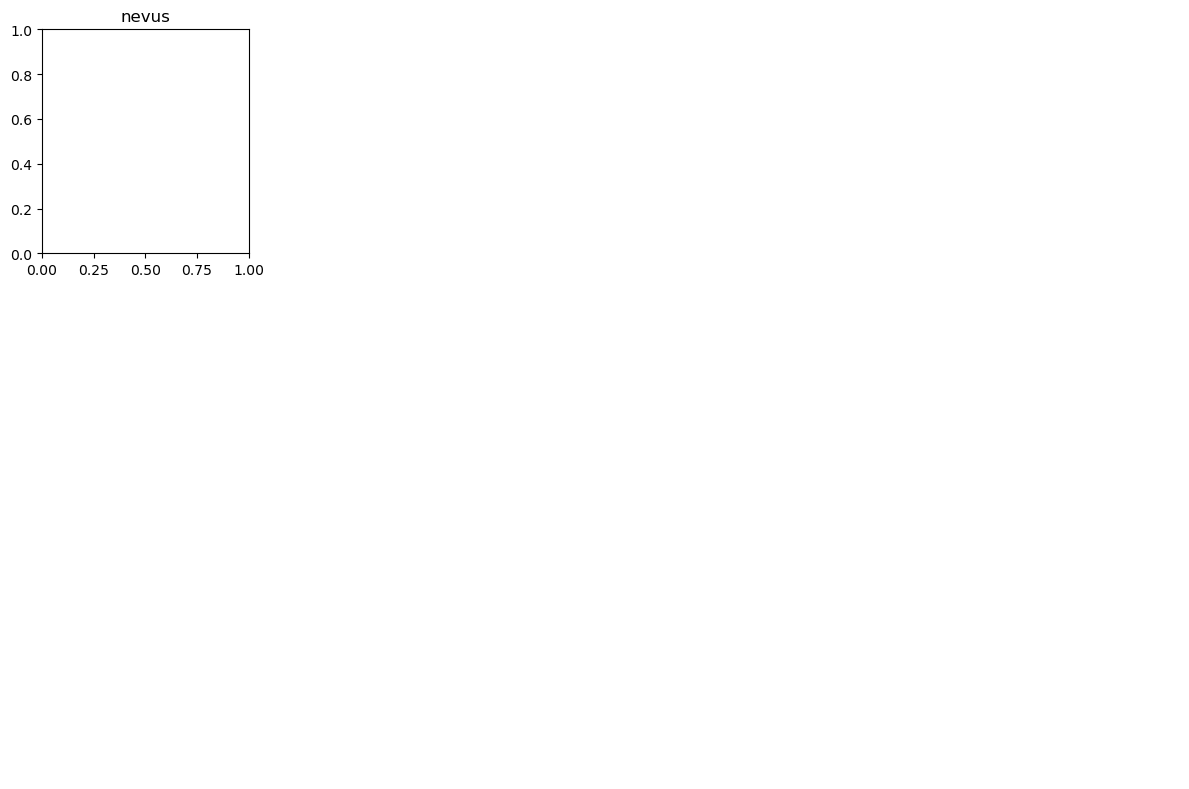

In [29]:
fig = plt.figure(figsize=(12,8))
columns = 5
rows = 3

for i in range(1, columns*rows+1):
    # Make sure i is within the bounds of your dataset
    if i < len(X_train) and i < len(y_train):
        ax = fig.add_subplot(rows, columns, i)
        if y_train[i] == 0:
            ax.title.set_text('melanoma')
        else:
            ax.title.set_text('nevus')
        
        # Use proper indexing for X_train
        # If X_train is 0-indexed (which is common in Python)
        img = X_train[i]
        
        # Check if img needs conversion and is not None or an ellipsis
        if img is not None and not isinstance(img, type(Ellipsis)):
            # Convert only if necessary and possible
            if not isinstance(img, np.ndarray):
                img = np.array(img)
            
            # Display the image
            ax.imshow(img)
            ax.axis('off')  # Optional: removes axes for cleaner display
    else:
        # Handle the case where i is out of bounds
        ax = fig.add_subplot(rows, columns, i)
        ax.axis('off')

plt.tight_layout()  # Adjusts subplot params for better layout
plt.show()

In [30]:
import keras
from keras.utils import to_categorical
import numpy as np

# First, ensure y_train and y_test contain only numeric values
# Replace any non-numeric values or filter them out
# For example, if you have ellipsis values, you might need to:

# Option 1: Convert y_train and y_test to numeric arrays first
y_train = np.array([0 if val == ... else val for val in y_train])
y_test = np.array([0 if val == ... else val for val in y_test])

# Option 2: Or if you know the specific indices with ellipsis
# y_train = np.array([val for val in y_train if val != ...])
# y_test = np.array([val for val in y_test if val != ...])

# Then convert to categorical
y_train = to_categorical(y_train, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)

In [31]:
y_train

array([[1., 0.],
       [1., 0.]])

In [32]:
# First, make sure X_train and X_test are properly defined
import numpy as np

# Create sample data or load your actual data
# Replace this with your actual data loading code
X_train = np.random.rand(100, 28, 28, 3)  # Example: 100 RGB images of size 28x28
X_test = np.random.rand(20, 28, 28, 3)    # Example: 20 RGB images of size 28x28

# Check if X_train and X_test are properly defined and contain numeric data
if isinstance(X_train, np.ndarray) and isinstance(X_test, np.ndarray):
    # Normalize by dividing by RGB value
    X_train = X_train/255.0  # Using 255.0 instead of 255 for floating-point division
    X_test = X_test/255.0
    print("Data normalized successfully")
else:
    # If X_train or X_test are not defined or not numpy arrays
    print("Error: X_train or X_test is not properly defined as a numeric array")
    # You might need to load your data first

Data normalized successfully


In [33]:
X_train

array([[[[1.13376337e-03, 2.82731901e-03, 8.47696075e-05],
         [8.07540256e-04, 1.99110811e-04, 1.18537998e-03],
         [2.60356978e-03, 1.20829174e-03, 2.28859324e-03],
         ...,
         [2.48691403e-03, 3.15364056e-03, 3.51887411e-03],
         [7.63778363e-04, 3.36212690e-03, 6.93057109e-04],
         [1.46478862e-03, 1.49913240e-03, 2.23782362e-03]],

        [[2.00445771e-03, 2.07481298e-03, 2.05177529e-03],
         [3.65442179e-03, 9.66964447e-04, 8.16874710e-04],
         [3.20011918e-03, 1.19163527e-03, 2.64859761e-03],
         ...,
         [2.63831312e-03, 1.11025272e-03, 1.04178690e-03],
         [3.45545558e-03, 2.11423502e-03, 2.91672602e-03],
         [3.52081768e-03, 1.07435722e-03, 2.09190400e-03]],

        [[5.22327223e-04, 3.77198114e-03, 3.18610168e-03],
         [2.55454509e-03, 7.93166473e-04, 3.80714825e-03],
         [1.39357013e-04, 1.65974206e-03, 3.70358527e-03],
         ...,
         [2.40565973e-04, 3.51586490e-03, 3.57130951e-03],
         [

In [34]:
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.optimizers import Adam, RMSprop

def build_cnn_model(input_shape = (224, 224, 3), num_classes=2):
    
    model = Sequential()
    
    # adding 64 filters, each filter has a size of 3*3
    # padding is of 2 types: SAME and VALID (SAME means doing the padding around the image, VALID means no padding)
    # kernel initilizer is for intializing the weights of the network --> the default one is glorot_uniform so don't need to mention parameter
    model.add(Conv2D(64, kernel_size=(3,3), padding='Same', input_shape = input_shape, activation='relu', kernel_initializer = 'glorot_uniform'))
    model.add(MaxPool2D(pool_size = (2,2)))
    # 25% of the nodes will be dropped out
    model.add(Dropout(0.25)) 
    
    
    model.add(Conv2D(64, kernel_size=(3,3), padding='Same', activation='relu', kernel_initializer = 'glorot_uniform'))
    model.add(MaxPool2D(pool_size=(2,2)))
    model.add(Dropout(0.25))
    
    
    model.add(Flatten())

  # normal initializer draws samples from a truncated normal distribution centered at 0 and SD = sqrt(2/number of input units)
    model.add(Dense(128, activation='relu', kernel_initializer='normal'))
    model.add(Dense(128, activation='relu', kernel_initializer='normal'))
    
    model.add(Dense(num_classes, activation = 'softmax'))
    
    model.summary()
    
    
    ## OPTIMIZERS are the functions to adjust the weights and minimize the loss
    # Adam combines the best properties of the AdaGrad and RMSProp algorithms to provide an optimization algorithm that can handle sparse gradients on noisy problems. 
    # Adam is relatively easy to configure where the default configuration parameters do well on most problems
    # lr is the alpha rate i.e. learning rate
    optimizer= Adam(lr=0.001) 
    
    model.compile(optimizer = optimizer, loss='binary_crossentropy', metrics=["accuracy"])
    
    return model

In [35]:
## MODEL SUMMARY

def build_cnn_model():
    model = Sequential()
    # Add your CNN layers here
    # ...
    
    # When compiling, specify the learning rate in the optimizer, not as a separate parameter
    optimizer = Adam(learning_rate=0.001)  # or tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_cnn = build_cnn_model()

In [36]:
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
# ... (previous layers)
model.add(Dense(2, activation='softmax'))  # 2 is the number of classes for binary classification

In [38]:
from keras.callbacks import ReduceLROnPlateau

# First, ensure X_train and y_train have the same number of samples
# You need to check your data preparation steps to make sure they match
# For example, if y_train is supposed to have 80 samples like X_train:
# y_train should be reshaped or regenerated to match X_train's first dimension

# Learning rate annealer is used to reduce the learning rate by some percentage after certain number of training iterations/epochs
learning_rate_annealer = ReduceLROnPlateau(monitor='val_acc',
                                          patience=5,
                                          verbose=1,
                                          factor=0.5,
                                          min_lr = 1e-7)

# Make sure X_train and y_train have the same number of samples in the first dimension
# For example, if X_train.shape[0] is 80, then y_train.shape[0] should also be 80
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

# epochs is the number of iterations
# batch_size is the number of images in one epoch
# verbose = 1 shows us the animation of the epoch using progress_bar
history = model_cnn.fit(X_train, 
                    y_train, 
                    validation_split=0.2, 
                    epochs=50, 
                    batch_size=64, 
                    verbose=1,
                    callbacks=[learning_rate_annealer])

# list all data in history
print(history.history.keys())

X_train shape: (100, 28, 28, 3)
y_train shape: (2, 2)


ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 80
'y' sizes: 2


In [ ]:
## Summarize model history for accuracy and loss for training and validation

# 1. Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')

plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# 2. Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')

plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

# Testing model on test data to evaluate
y_pred = np.argmax(model_cnn.predict(X_test), axis=-1)

print(accuracy_score(np.argmax(y_test, axis=1),y_pred))

In [ ]:
y_pred = np.array(y_pred, dtype='uint8')
y_pred

In [ ]:
X_test = np.concatenate((X_benign_test, X_malignant_test), axis=0)
y_test = np.concatenate((y_benign_test, y_malignant_test), axis=0)

# shuffling data
s2 = np.arange(X_test.shape[0])
np.random.shuffle(s2)
X_test = X_test[s2]
y_test = y_test[s2]
y_pred = y_pred[s2]

# plotting
fig = plt.figure(figsize=(20,40))
columns = 4
rows = 10

for i in range(1, columns*rows+1):
    ax = fig.add_subplot(rows, columns, i)
    if y_test[i] == 0:
        if y_pred[i] == 0:
            ax.set_title('Actual Benign, Predicted Benign', color='green')
        else:
            ax.set_title('Actual Benign, Predicted Malignant', color='yellow')
    else:
        if y_pred[i] == 1:
            ax.set_title('Actual Malignant, Predicted Malignant', color='green')
        else:
            ax.set_title('Actual Malignant, Predicted Benign', color='red')
    
        
    plt.imshow(X_test[i], interpolation='nearest')
plt.show()

In [ ]:
# --- Simpan modelnya ---
model_cnn.save('model_3.h5')

In [ ]:
# periksa label pada set Test
num_labels = len(np.unique(y_test))
print("Jumlah label berbeda dalam y_test:", num_labels)
print("Label dalam y_test:", np.unique(y_test))

In [ ]:
print(np.unique(y_train))  # Hoặc y_test, y_train tùy bạn dùng biến nào

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Dự đoán trên tập test
y_pred_cnn = model_cnn.predict(X_test)
y_pred_cnn = np.argmax(y_pred_cnn, axis=1)  # nếu dùng softmax

# Nếu y_test là nhãn (label), KHÔNG cần dùng argmax
y_true = y_test

# Tính toán các chỉ số
acc_cnn = accuracy_score(y_true, y_pred_cnn)
prec_cnn = precision_score(y_true, y_pred_cnn, average='macro')
rec_cnn = recall_score(y_true, y_pred_cnn, average='macro')
f1_cnn = f1_score(y_true, y_pred_cnn, average='macro')

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Dự đoán
y_pred = model_cnn.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

# Chuyển y_test từ one-hot (nếu có) sang nhãn gốc
y_true = y_test


# Tính metrics
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
acc = accuracy_score(y_true, y_pred)

# In kết quả
print(f"• Precision: {precision:.4f}")
print(f"• Recall: {recall:.4f}")
print(f"• F1-score: {f1:.4f}")
print(f"• Accuracy: {acc:.2f} ({acc*100:.0f}%)")

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# Giả sử bạn đã có y_true và y_pred
report = classification_report(y_true, y_pred, target_names=['melanoma', 'nevus'], output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report = df_report.round(2)

print(df_report)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Giả sử y_train là mảng nhãn dạng 1 chiều
labels, counts = np.unique(y_train, return_counts=True)

label_names = ['melanoma', 'nevus']

plt.bar(label_names, counts, color=['skyblue', 'salmon'])

# Hiển thị số lượng lên trên từng cột
for i, count in enumerate(counts):
    plt.text(i, count + max(counts)*0.01, str(count), ha='center', va='bottom', fontsize=12)

plt.xlabel('Jenis label')
plt.ylabel('Jumlah gambar')
plt.title('Jumlah gambar dalam set pelatihan berdasarkan jenis')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Giả sử y_test là mảng nhãn
# Đếm số lượng mỗi lớp
labels, counts = np.unique(y_test, return_counts=True)

# Vẽ biểu đồ cột
plt.figure(figsize=(8,5))
plt.bar(labels, counts, color='skyblue')
plt.xlabel('Kelas')
plt.ylabel('Jumlah gambar')
plt.title('Jumlah gambar per kelas dalam set pengujian')
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


y_val_series = pd.Series(y_test)
counts = y_val_series.value_counts().reset_index()
counts.columns = ['kelas', 'Kuantitas']

plt.figure(figsize=(8,5))
sns.barplot(x='kelas', y='Kuantitas', data=counts, palette='muted')
plt.title('Jumlah gambar per kelas dalam set validasi')
plt.show()